<a href="https://colab.research.google.com/github/DarshanSubramani/-Python-Charts-for-Insights/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd

# Creating dataset
data = {
    "study_hours": [5,2,4,6,3,7,2,5,4,6],
    "sleep_hours": [7,5,6,8,5,7,6,7,6,7],
    "screen_time": [2,6,3,2,5,1,7,3,4,2],
    "attendance": [85,60,75,90,65,95,55,80,70,88],
    "assignments": [8,4,6,9,5,10,3,7,6,9],
    "performance": ["Good","Poor","Average","Good","Poor","Good","Poor","Good","Average","Good"]
}

df = pd.DataFrame(data)

df.head()

,study_hours,sleep_hours,screen_time,attendance,assignments,performance
0,5,7,2,85,8,Good
1,2,5,6,60,4,Poor
2,4,6,3,75,6,Average
3,6,8,2,90,9,Good
4,3,5,5,65,5,Poor


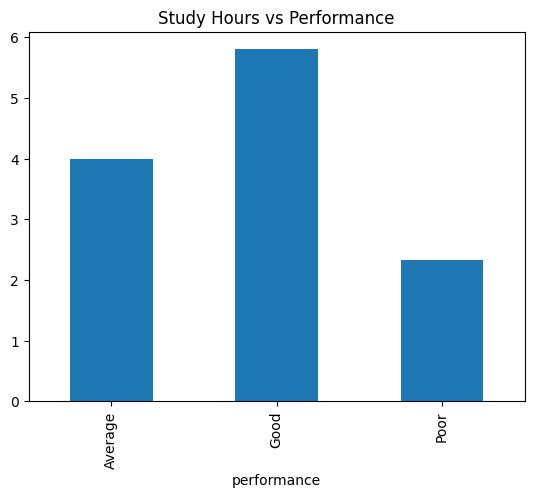

In [5]:
import matplotlib.pyplot as plt

df.groupby("performance")["study_hours"].mean().plot(kind="bar")

plt.title("Study Hours vs Performance")
plt.show()

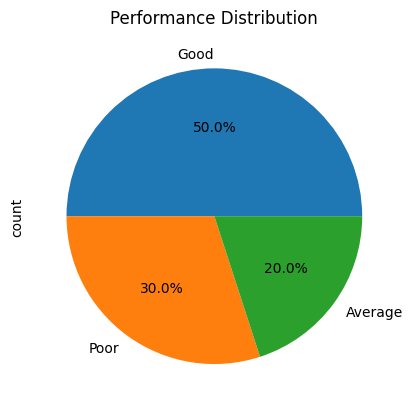

In [10]:
df["performance"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Performance Distribution")
plt.show()

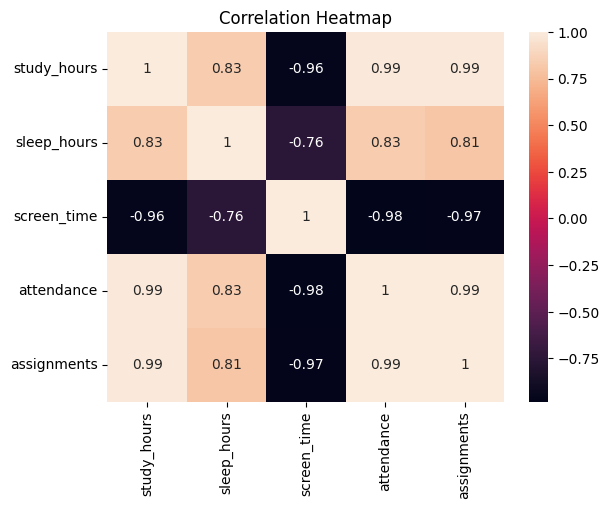

In [15]:
import seaborn as sns

sns.heatmap(df.drop("performance", axis=1).corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [24]:
# Check missing values
print(df.isnull().sum())

# Features & target
X = df.drop("performance", axis=1)
y = df["performance"]

study_hours    0
sleep_hours    0
screen_time    0
attendance     0
assignments    0
performance    0
dtype: int64


In [29]:

from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:

from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         1
        Poor       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [36]:
new_data = pd.DataFrame([[2, 5, 6, 60, 4]],
                        columns=["study_hours", "sleep_hours", "screen_time", "attendance", "assignments"])

result = model.predict(new_data)

print("Predicted Performance:", result[0])

Predicted Performance: Poor


In [37]:
if result[0] == "Poor":
    print("Suggestion: Increase study hours and reduce screen time.")
elif result[0] == "Average":
    print("Suggestion: Improve consistency and complete assignments.")
else:
    print("Great! Keep maintaining your habits.")

Suggestion: Increase study hours and reduce screen time.
